Load Neccesary Libraries

In [1]:
# Import Libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

Read .txt file, then define constants and arrays of physical quantities

In [2]:
# Import .txt files
df = pd.read_csv(f"BBO_Sample/BBO1(more_granular).txt", sep=r"\s+")

# speed of light
c = 299792458

position = df["Position(mm)"]
voltage = df["Voltage(V)"] 
time = 2 * (position / 10**3) / c

# Convert voltage from volts to microvolts (10^-6)
voltage = voltage * 10**6

# Convert time from seconds to femtoseconds (10^-15)
time = time * 10**15

Plot voltage w.r.t. position

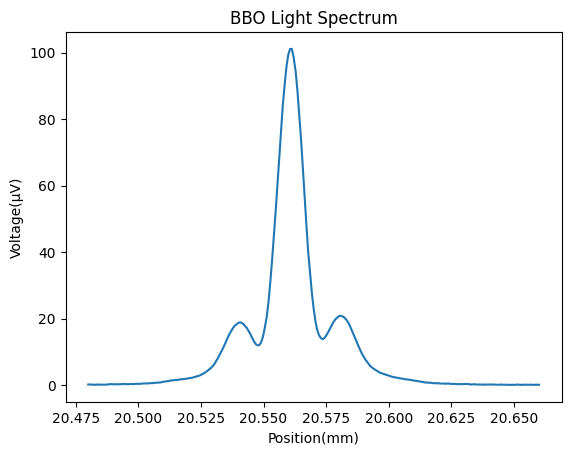

In [3]:
plt.figure()
plt.plot(position, voltage)
plt.xlabel("Position(mm)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("BBO Light Spectrum")

plt.show()

Plot voltage w.r.t. time

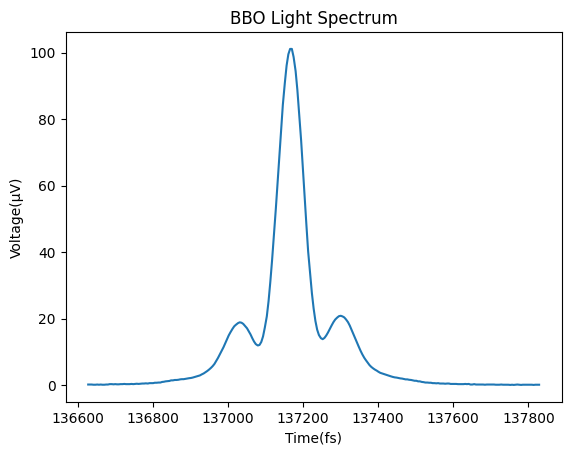

In [21]:
plt.figure()
plt.plot(time, voltage)
plt.xlabel("Time(fs)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("BBO Light Spectrum")

plt.show()

**Gaussian Model Fitting**

In [22]:
# Gaussian Model
def gaussian_model(t, A, t0, std):
    return A * np.exp( (-((t - t0) / std)**2) / 2)

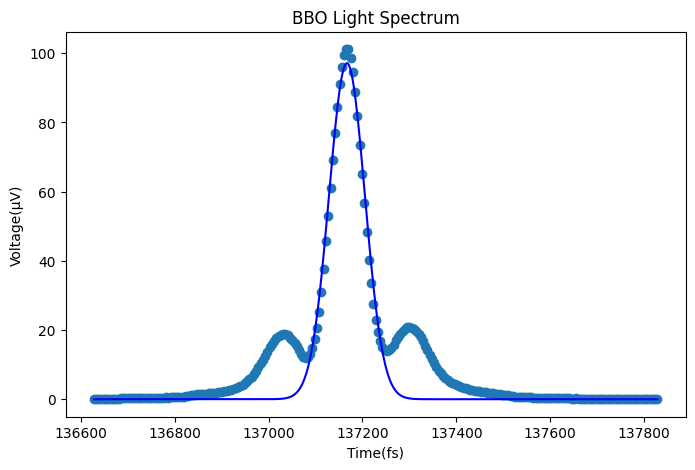

In [24]:
# Fit model to data
p0 = [
    max(voltage),                 # A
    time[np.argmax(voltage)],     # t0
    (max(time) - min(time)) / 10  # std guess
]

params_gauss, _ = curve_fit(gaussian_model, time, voltage, p0=p0)
A_gauss, t0_gauss, std_gauss = params_gauss

t_smooth = np.linspace(time.iloc[0], time.iloc[-1], 500)


# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time, voltage)

# Plot gaussian
plt.plot(
    t_smooth,
    gaussian_model(t_smooth, A_gauss, t0_gauss, std_gauss),
    color = 'blue'
)
plt.xlabel("Time(fs)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("BBO Light Spectrum")
plt.show()

Compute Indices of FWHM, then take the difference to find pulse duration

In [26]:
v_gauss = gaussian_model(t_smooth, A_gauss, t0_gauss, std_gauss)

V_max = np.max(v_gauss)
half = V_max / 2

indices = np.where(v_gauss >= half)[0]
t1 = t_smooth[indices[0]]
t2 = t_smooth[indices[-1]]

pulse_duration = t2 - t1

print(f"\u0394τ = {pulse_duration} femtoseconds")

print(f"\u0394t = {pulse_duration / np.sqrt(2)} femtoseconds")

Δτ = 86.63307963463012 femtoseconds
Δt = 61.25883808472114 femtoseconds


**Lorentzian Model Fitting**

In [27]:
# Lorentzian Model
def lorentzian_model(t, A, fwhm, t0):
    gamma = fwhm / 2.0
    
    return A * gamma**2 / ((t - t0)**2 + gamma**2)

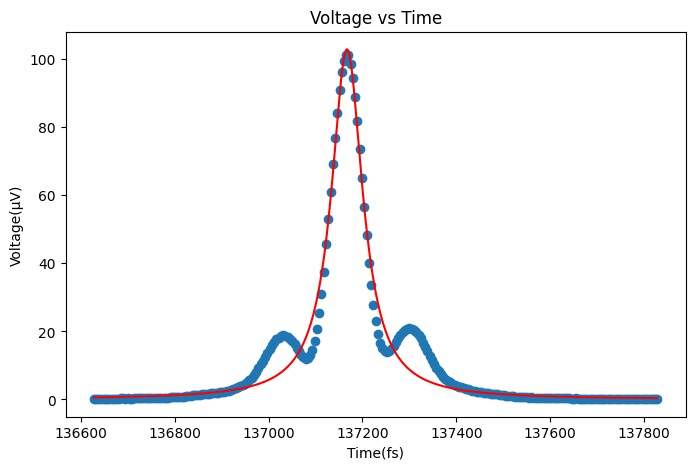

In [28]:
# Plot lorentzian

# Fit model to data
p0 = [
    max(voltage),                 # A
    time[np.argmax(voltage)],     # t0
    (max(time) - min(time)) / 10  # std guess
]

params_lorentz, _ = curve_fit(lorentzian_model, time, voltage, p0 = p0)
A_lorentz, fwhm_lorentz, t0_lorentz = params_lorentz

t_smooth = np.linspace(time.iloc[0], time.iloc[-1], 500)

# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time, voltage)

plt.plot(
    t_smooth,
    lorentzian_model(t_smooth, A_lorentz, fwhm_lorentz, t0_lorentz),
    color = 'red'
)

plt.xlabel("Time(fs)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("Voltage vs Time")
plt.show()

In [29]:
v_loren = lorentzian_model(t_smooth, A_lorentz, fwhm_lorentz, t0_lorentz)

V_max = np.max(v_loren)
half = V_max / 2

indices = np.where(v_loren >= half)[0]
t1 = t_smooth[indices[0]]
t2 = t_smooth[indices[-1]]

pulse_duration = t2 - t1

print(f"\u0394τ = {pulse_duration} femtoseconds")

print(f"\u0394t = {pulse_duration / np.sqrt(2)} femtoseconds")

Δτ = 77.0071818974684 femtoseconds
Δt = 54.45230051976585 femtoseconds
